# Predict the electricity price

* Features:
    - electricy demand prediction
    - PV generation prediction
    - wind generation prediction
    - residual load (PV generation + wind generation - electricity demand)
*

In [49]:
# Set a consistent style for all plots
import matplotlib.pyplot as plt
plt.rcParams.update({
    'axes.grid':      True,
    'grid.color':     '#DCDCDC',
    'grid.linewidth': 0.5,
    'grid.linestyle': '-',
    'axes.axisbelow': True,
    'axes.facecolor': 'white',
    'font.family':    'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.titlepad':  13,
    'axes.labelsize': 10,
    'axes.labelpad':  8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'legend.frameon':    True,
    'legend.facecolor':  'white',
    'legend.edgecolor':  '#DCDCDC',
    'legend.framealpha': 1.0,
    'legend.fontsize':   9,
})

import sys
import os

# Add the src directory to the system path to allow importing custom modules
project_root = os.path.abspath("..")
src_dir = os.path.join(project_root, "src")
util_dir = os.path.join(project_root, "util")

if project_root not in sys.path:
    sys.path.insert(0, project_root)
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)
if util_dir not in sys.path:
    sys.path.insert(0, util_dir)


import warnings
warnings.filterwarnings('ignore')

# Enable autoreload to automatically reload modules when they are edited
%load_ext autoreload
%autoreload 2
    
from src.config import *
from util.weather_weighted import *
from src.etl_price import *
from src.fetch_price_data import *
from src.train_predict_model import *
from util.time_features import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [52]:
import numpy as np
import pandas as pd
from pathlib import Path

#update_price_database()

# One-liner data preparation: loads, merges, engineers features, returns training-ready dataset 
df_price_model = prepare_price_model_dataset()

print("model rows:", len(df_price_model))
print("time range:", df_price_model["time"].min(), "->", df_price_model["time"].max())
print("feature count:", len(df_price_model.columns) - 2)  # Subtracting 'time' and target column
display(df_price_model.shape)

Series catalog seeded/updated rows: 14

Current SMARD data status:
  price_de_lu_eur_mwh         :  65255 rows | max: 2026-06-11T21:00:00Z
  gen_wind_onshore_mwh        :  65224 rows | max: 2026-06-10T14:00:00Z
  gen_wind_offshore_mwh       :  65224 rows | max: 2026-06-10T14:00:00Z
  gen_pv_mwh                  :  65224 rows | max: 2026-06-10T14:00:00Z
  gen_other_conventional_mwh  :  65224 rows | max: 2026-06-10T14:00:00Z
  forecast_wind_onshore_mwh   :  65255 rows | max: 2026-06-11T21:00:00Z
  forecast_wind_offshore_mwh  :  65255 rows | max: 2026-06-11T21:00:00Z
  forecast_pv_mwh             :  65255 rows | max: 2026-06-11T21:00:00Z

SMARD series up to date — skip SMARD fetch.

Current Open-Meteo data status:
  pv_weather_shortwave_radiation:  65207 rows | max: 2026-06-09T21:00:00Z
  pv_weather_direct_radiation :  65207 rows | max: 2026-06-09T21:00:00Z
  pv_weather_diffuse_radiation:  65207 rows | max: 2026-06-09T21:00:00Z
  pv_weather_cloud_cover      :  65207 rows | max: 2026-06-09

(64864, 60)

In [5]:
# Train-test split by date
split_date = pd.Timestamp("2025-10-01", tz="UTC")
price_features_train, price_target_train, price_features_test, price_target_test = train_test_split_by_date(
    df = df_price_model, date_column='time', target_column="price_de_lu_eur_mwh", split_date=split_date
)
print("Training set:", price_features_train.shape, price_target_train.shape)
print("Testing set:", price_features_test.shape, price_target_test.shape)

Training set: (58818, 58) (58818,)
Testing set: (6046, 58) (6046,)


In [50]:
# predict price for tomorrow
import datetime

#df_tomorrow = prepare_data_for_price_prediction_tomorrow()
df_tomorrow = prepare_data_for_price_prediction_operational()

Series catalog seeded/updated rows: 14

Current SMARD data status:
  price_de_lu_eur_mwh         :  65255 rows | max: 2026-06-11T21:00:00Z
  gen_wind_onshore_mwh        :  65224 rows | max: 2026-06-10T14:00:00Z
  gen_wind_offshore_mwh       :  65224 rows | max: 2026-06-10T14:00:00Z
  gen_pv_mwh                  :  65224 rows | max: 2026-06-10T14:00:00Z
  gen_other_conventional_mwh  :  65224 rows | max: 2026-06-10T14:00:00Z
  forecast_wind_onshore_mwh   :  65255 rows | max: 2026-06-11T21:00:00Z
  forecast_wind_offshore_mwh  :  65255 rows | max: 2026-06-11T21:00:00Z
  forecast_pv_mwh             :  65255 rows | max: 2026-06-11T21:00:00Z

SMARD series up to date — skip SMARD fetch.

Current Open-Meteo data status:
  pv_weather_shortwave_radiation:  65207 rows | max: 2026-06-09T21:00:00Z
  pv_weather_direct_radiation :  65207 rows | max: 2026-06-09T21:00:00Z
  pv_weather_diffuse_radiation:  65207 rows | max: 2026-06-09T21:00:00Z
  pv_weather_cloud_cover      :  65207 rows | max: 2026-06-09

In [53]:
# print time range of df_price_model and df_tomorrow
print("df_price_model time range:", df_price_model["time"].min(), "->", df_price_model["time"].max())
print("df_tomorrow time range:", df_tomorrow["time"].min(), "->", df_tomorrow["time"].max())

df_price_model time range: 2019-01-15 01:00:00+01:00 -> 2026-06-09 23:00:00+02:00
df_tomorrow time range: 2026-06-11 00:00:00+02:00 -> 2026-06-11 23:00:00+02:00


Predicted price for tomorrow (LightGBM) EUR/MWh: 
[ 94.85585412  96.4648835   95.52824228  95.66315496  95.89606757
  92.50377305 106.14932022 143.71427042 120.46891136 110.14686861
  87.02013675  59.75780818  51.03027058  48.78327315  47.67256282
  48.77404475  64.8743449   87.15519444 102.72134864 110.65143599
 110.14673837  98.27086488 100.45547048 102.31568875] 
Predicted price for tomorrow (XGBoost) EUR/MWh: 
[298.17496 291.04333 289.66904 225.53777 227.78337 288.5286  296.86606
 314.1898  286.92966 257.5291  236.54721 216.25136 192.79668 167.3957
 186.4874  198.90578 237.07178 230.89006 243.14998 249.72829 282.97763
 260.56238 240.41075 235.5565 ] 


64816    140.43
64817    134.24
64818    132.71
64819    127.67
64820    130.18
64821    138.56
64822    150.68
64823    145.68
64824    124.88
64825    100.90
64826     75.92
64827     55.64
64828     54.48
64829     55.22
64830     68.67
64831     88.85
64832    102.58
64833    128.88
64834    151.33
64835    199.32
64836    208.90
64837    185.75
64838    152.37
64839    128.20
Name: price_de_lu_eur_mwh, dtype: float64

time
0     115.881667
1     108.005000
2     103.016667
3      97.510000
4      98.780000
5      97.590000
6      98.838333
7      98.498333
8      87.645000
9      65.070000
10     44.610000
11     32.116667
12     23.256667
13     15.201667
14     14.858333
15     24.770000
16     51.805000
17     81.825000
18    113.223333
19    140.701667
20    155.480000
21    151.993333
22    138.278333
23    123.600000
Name: price_de_lu_eur_mwh, dtype: float64

prices of daybeforeyesterday:
 [140.43, 134.24, 132.71, 127.67, 130.18, 138.56, 150.68, 145.68, 124.88, 100.9, 75.92, 55.64, 54.48, 55.22, 68.67, 88.85, 102.58, 128.88, 151.33, 199.32, 208.9, 185.75, 152.37, 128.2]
prices of last 7 days:
 time
0     115.881667
1     108.005000
2     103.016667
3      97.510000
4      98.780000
5      97.590000
6      98.838333
7      98.498333
8      87.645000
9      65.070000
10     44.610000
11     32.116667
12     23.256667
13     15.201667
14     14.858333
15     24.770000
16     51.805000
17     81.825000
18    113.223333
19    140.701667
20    155.480000
21    151.993333
22    138.278333
23    123.600000
Name: price_de_lu_eur_mwh, dtype: float64


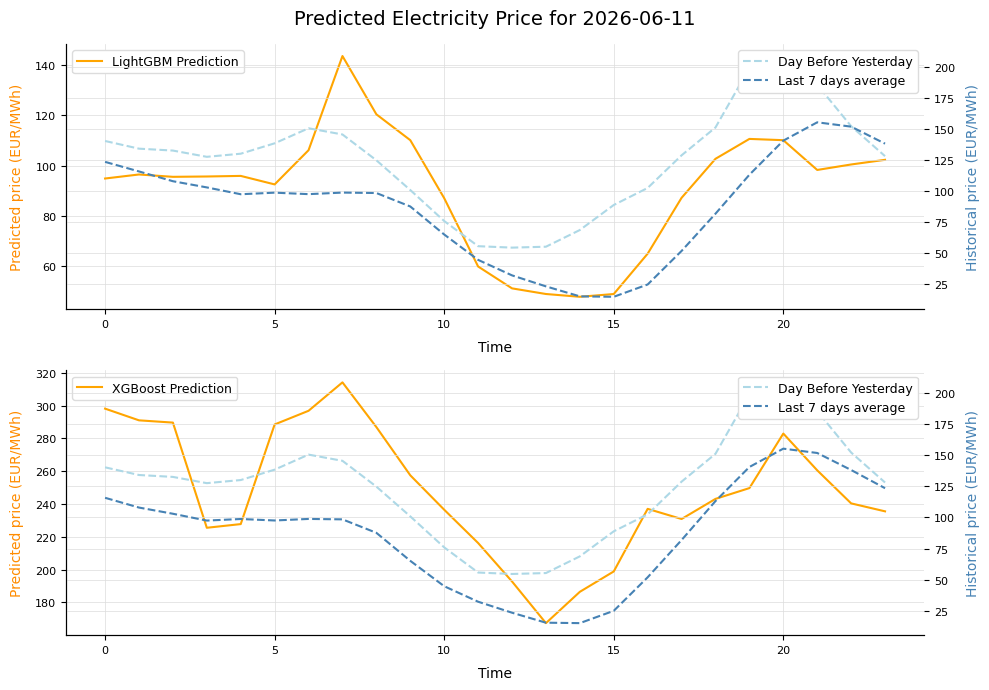

In [54]:
# plot predition for tomorrow and compare with historical price distribution
price_model_lgbm = load_model_from_pickle('../models/price_lgbm_model.pkl')
price_model_xgb = load_model_from_pickle('../models/price_xgb_model.pkl')
price_features_train = price_model_lgbm.feature_name_

pred_price_lgbm = price_model_lgbm.predict(df_tomorrow[price_features_train])
pred_price_xgb = price_model_xgb.predict(df_tomorrow[price_features_train]) 
print(f"Predicted price for tomorrow (LightGBM) EUR/MWh: \n{pred_price_lgbm} ")
print(f"Predicted price for tomorrow (XGBoost) EUR/MWh: \n{pred_price_xgb} ")

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

daybeforeyesterday = (pd.Timestamp.now(tz='UTC').normalize() - pd.Timedelta(days=2)).date()
tomorrow = (pd.Timestamp.now(tz='UTC').normalize() + pd.Timedelta(days=1)).date()
time_range = range(24)  # Assuming hourly data for one day)

df_price_daybeforeyesterday = df_price_model.loc[df_price_model['time'].dt.date == daybeforeyesterday, 'price_de_lu_eur_mwh']
display(df_price_daybeforeyesterday)

# mean hourly price of last 7 days
# filter last 7 days
last_7days_start = pd.Timestamp.now(tz='UTC').normalize() - pd.Timedelta(days=7)
last_7days_end = pd.Timestamp.now(tz='UTC').normalize() - pd.Timedelta(days=1)
df_price_last7days = df_price_model.loc[(df_price_model['time'] >= last_7days_start) & (df_price_model['time'] < last_7days_end), 'price_de_lu_eur_mwh'].groupby(df_price_model['time'].dt.hour).mean()
display(df_price_last7days)

print('prices of daybeforeyesterday:\n', df_price_daybeforeyesterday.to_list())
print('prices of last 7 days:\n', df_price_last7days)

fig, axes = plt.subplots(2, 1, figsize=(10, 7))
sns.lineplot(x=time_range, y=pred_price_lgbm, color='orange', ax=axes[0])
#axes[0].set_title(f'Predicted electricity price for {tomorrow} by LightGBM')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Predicted price (EUR/MWh)', color='darkorange')
axes[0].legend(['LightGBM Prediction'], loc='upper left')
ax1_twinx = axes[0].twinx()
sns.lineplot(x=df_price_model['time'].dt.hour, y=df_price_daybeforeyesterday, color='lightblue', linestyle='--', ax=ax1_twinx, label='Day Before Yesterday')
sns.lineplot(x=df_price_model['time'].dt.hour, y=df_price_last7days, color='steelblue', linestyle='--', ax=ax1_twinx, label='Last 7 days average')
ax1_twinx.legend(loc='upper right')
ax1_twinx.set_ylabel('Historical price (EUR/MWh)', color='steelblue')

sns.lineplot(x=time_range, y=pred_price_xgb, color='orange', ax=axes[1])
#axes[1].set_title(f'Predicted electricity price for {tomorrow} by XGBoost')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Predicted price (EUR/MWh)', color='darkorange')
axes[1].legend(['XGBoost Prediction'], loc='upper left')
ax2_twinx = axes[1].twinx()
sns.lineplot(x=time_range, y=df_price_daybeforeyesterday, color='lightblue', linestyle='--', ax=ax2_twinx, label='Day Before Yesterday')
sns.lineplot(x=time_range, y=df_price_last7days, color='steelblue', linestyle='--', ax=ax2_twinx, label='Last 7 days average')
ax2_twinx.legend(loc='upper right')
ax2_twinx.set_ylabel('Historical price (EUR/MWh)', color='steelblue')

plt.suptitle(f'Predicted Electricity Price for {tomorrow}', fontsize=14)
plt.tight_layout()
plt.show()